# Mean Shift — Кластеризация

**Mean Shift** — непараметрический алгоритм кластеризации, основанный на оценке плотности ядра (KDE). Каждая точка итеративно сдвигается к среднему значению точек в своей окрестности (bandwidth), «всплывая» к локальному максимуму плотности. Точки, сошедшиеся к одному пику, образуют кластер. Число кластеров определяется автоматически. Связан с поиском мод многомерного распределения.

**Датасет:** Red Wine Quality — физико-химические свойства красного вина и оценка качества сомелье.

## 2. Используемые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

## 3. Описание и демонстрация датасета

In [2]:
df = pd.read_csv('./winequality-red.csv')
print("Форма датасета:", df.shape)
print("\nПервые 10 строк:")
print(df.head(10).to_string())
print("\nОписательная статистика:")
print(df.describe().round(3).to_string())
print("\nРаспределение оценок качества:")
print(df['quality'].value_counts().sort_index())

Форма датасета: (1599, 12)

Первые 10 строк:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol  quality
0            7.4              0.70         0.00             1.9      0.076                 11.0                  34.0   0.9978  3.51       0.56      9.4        5
1            7.8              0.88         0.00             2.6      0.098                 25.0                  67.0   0.9968  3.20       0.68      9.8        5
2            7.8              0.76         0.04             2.3      0.092                 15.0                  54.0   0.9970  3.26       0.65      9.8        5
3           11.2              0.28         0.56             1.9      0.075                 17.0                  60.0   0.9980  3.16       0.58      9.8        6
4            7.4              0.70         0.00             1.9      0.076                 11.0                  34.0   0.9978  3.51       0.56  

## 4. Предварительная обработка

In [3]:
print("Пропущенные значения:", df.isnull().sum().sum())

X = df.drop('quality', axis=1).values
feature_names = df.drop('quality', axis=1).columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA для визуализации
pca_vis = PCA(n_components=2, random_state=42)
X_2d = pca_vis.fit_transform(X_scaled)

# Оценка bandwidth
bw_auto = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=300, random_state=42)
print(f"Автоматический bandwidth: {bw_auto:.4f}")
print("\nДанные после масштабирования (первые 5 строк):")
print(pd.DataFrame(X_scaled[:5], columns=feature_names).round(3).to_string())

Пропущенные значения: 0
Автоматический bandwidth: 3.2267

Данные после масштабирования (первые 5 строк):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density     pH  sulphates  alcohol
0         -0.528             0.962       -1.391          -0.453     -0.244               -0.466                -0.379    0.558  1.289     -0.579   -0.960
1         -0.299             1.967       -1.391           0.043      0.224                0.873                 0.624    0.028 -0.720      0.129   -0.585
2         -0.299             1.297       -1.186          -0.169      0.096               -0.084                 0.229    0.134 -0.331     -0.048   -0.585
3          1.655            -1.384        1.484          -0.453     -0.265                0.108                 0.412    0.664 -0.979     -0.461   -0.585
4         -0.528             0.962       -1.391          -0.453     -0.244               -0.466                -0.379    0.55

## 5. Тепловая карта корреляций

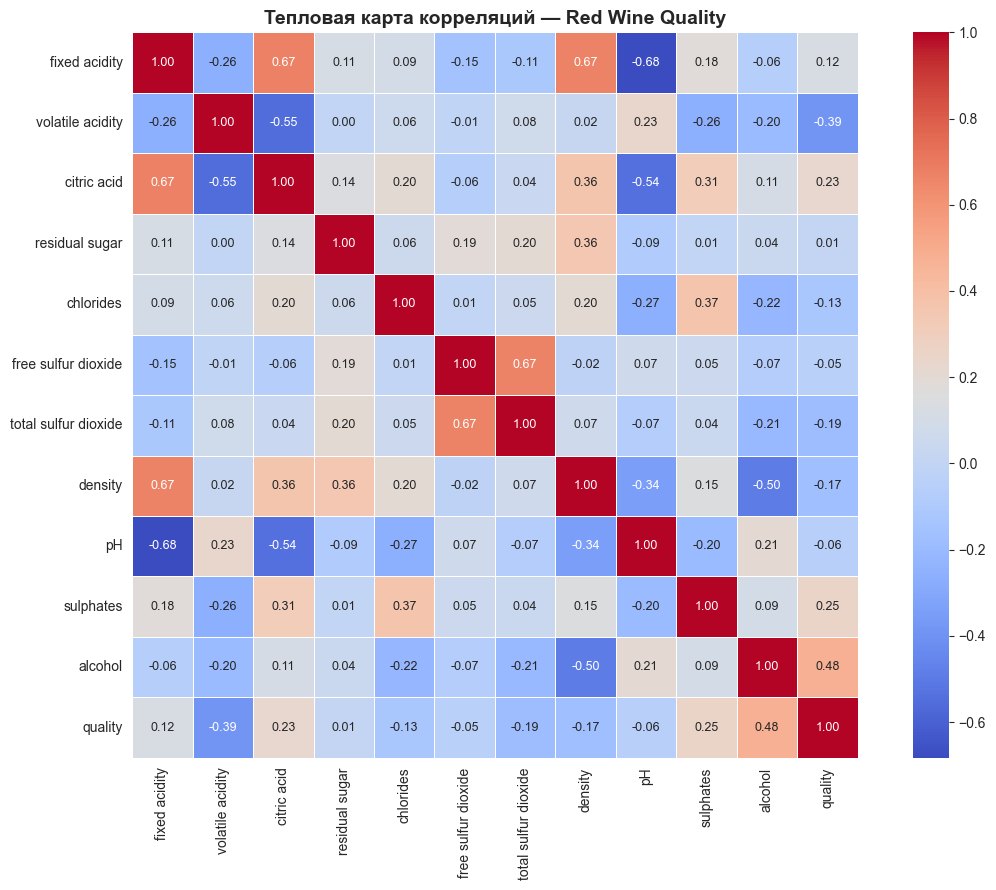

In [4]:
plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, annot_kws={'size':9})
plt.title('Тепловая карта корреляций — Red Wine Quality', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Обучение Mean Shift — метод локтя и силуэт

  bw=1.0  →  кластеров=589,  силуэт=0.2154
  bw=1.3  →  кластеров=289,  силуэт=0.1397
  bw=1.6  →  кластеров=138,  силуэт=0.0940
  bw=1.9  →  кластеров=74,  силуэт=0.0898
  bw=2.2  →  кластеров=43,  силуэт=0.0372
  bw=2.5  →  кластеров=27,  силуэт=0.0727
  bw=2.8  →  кластеров=19,  силуэт=0.1424
  bw=3.1  →  кластеров=13,  силуэт=0.2189
  bw=3.4  →  кластеров=9,  силуэт=0.3234
  bw=3.7  →  кластеров=9,  силуэт=0.3286


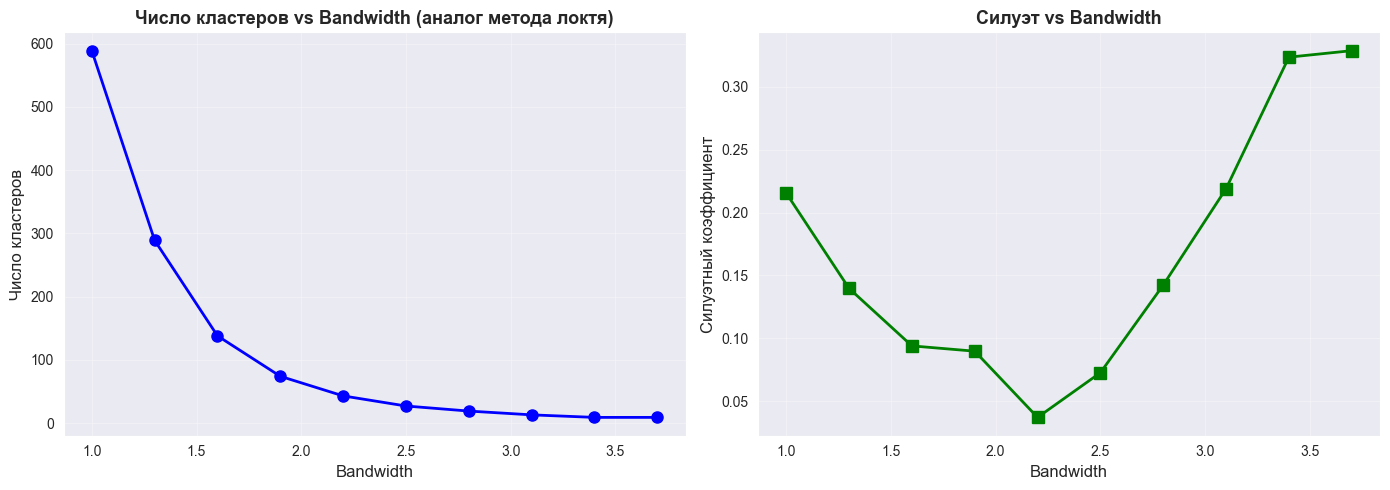


Лучший bandwidth: 3.7, силуэт: 0.3286


In [5]:
bw_range = np.arange(1.0, 4.0, 0.3)
sil_scores, cluster_counts = [], []

for bw in bw_range:
    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    lbl = ms.fit_predict(X_scaled)
    n_cl = len(np.unique(lbl))
    cluster_counts.append(n_cl)
    sil = silhouette_score(X_scaled, lbl) if n_cl >= 2 else -1
    sil_scores.append(sil)
    print(f"  bw={bw:.1f}  →  кластеров={n_cl},  силуэт={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(bw_range, cluster_counts, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Bandwidth', fontsize=12)
axes[0].set_ylabel('Число кластеров', fontsize=12)
axes[0].set_title('Число кластеров vs Bandwidth (аналог метода локтя)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(bw_range, sil_scores, 'gs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Bandwidth', fontsize=12)
axes[1].set_ylabel('Силуэтный коэффициент', fontsize=12)
axes[1].set_title('Силуэт vs Bandwidth', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best_bw = bw_range[np.argmax(sil_scores)]
print(f"\nЛучший bandwidth: {best_bw:.1f}, силуэт: {max(sil_scores):.4f}")

In [6]:
# Финальная модель
ms_final = MeanShift(bandwidth=best_bw, bin_seeding=True)
labels = ms_final.fit_predict(X_scaled)
n_cl = len(np.unique(labels))
print(f"Число кластеров: {n_cl}")
print(f"Силуэтный коэффициент: {silhouette_score(X_scaled, labels):.4f}")
print("Центры кластеров (в исходном масштабе):")
centers_orig = scaler.inverse_transform(ms_final.cluster_centers_)
print(pd.DataFrame(centers_orig, columns=feature_names).round(2).to_string())

Число кластеров: 9
Силуэтный коэффициент: 0.3286
Центры кластеров (в исходном масштабе):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol
0           8.08              0.53         0.24            2.30       0.08                15.02                 43.26      1.0  3.33       0.63    10.32
1           8.32              0.54         0.51            1.93       0.38                15.00                 53.86      1.0  3.07       1.17     9.37
2          10.05              0.52         0.44           14.60       0.21                51.50                 88.50      1.0  3.17       0.76     8.90
3           8.22              0.44         0.29            2.00       0.10                23.75                133.00      1.0  2.93       1.88     9.78
4          10.20              0.42         0.26           12.50       0.07                10.67                 41.00      1.0  3.15       0.68   

## 7. Прогнозы модели

In [7]:
df['cluster'] = labels
print("Распределение по кластерам:")
print(df['cluster'].value_counts().sort_index())
print("\nСредние значения по кластерам:")
print(df.groupby('cluster').mean().round(2).to_string())

Распределение по кластерам:
cluster
0    1527
1      23
2       4
3       9
4      10
5       6
6      13
7       1
8       6
Name: count, dtype: int64

Средние значения по кластерам:
         fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol  quality
cluster                                                                                                                                                                
0                 8.27              0.53         0.26            2.40       0.08                15.56                 45.18      1.0  3.32       0.64    10.43     5.64
1                 8.41              0.52         0.52            1.93       0.39                14.30                 51.91      1.0  3.08       1.16     9.42     5.35
2                10.05              0.52         0.44           14.60       0.21                51.50                 88.50      1.0  3.17      

## 8. Графики результатов

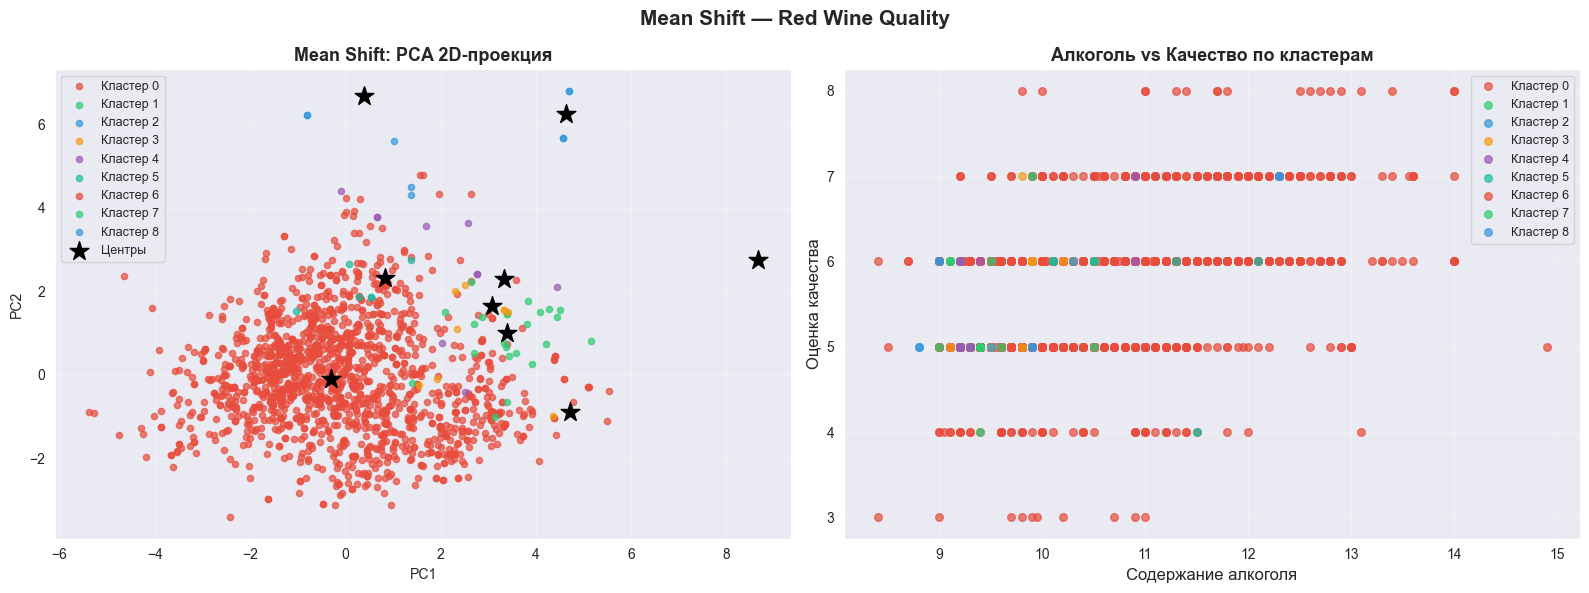

In [8]:
palette = ['#E74C3C','#2ECC71','#3498DB','#F39C12','#9B59B6','#1ABC9C']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA 2D
for i in np.unique(labels):
    mask = labels == i
    axes[0].scatter(X_2d[mask,0], X_2d[mask,1], c=palette[i%len(palette)], s=20, alpha=0.7, label=f'Кластер {i}')
centers_2d = pca_vis.transform(ms_final.cluster_centers_)
axes[0].scatter(centers_2d[:,0], centers_2d[:,1], c='black', s=200, marker='*', zorder=5, label='Центры')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('Mean Shift: PCA 2D-проекция', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Alcohol vs Quality scatter
for i in np.unique(labels):
    mask = labels == i
    axes[1].scatter(df.loc[mask,'alcohol'], df.loc[mask,'quality'],
                    c=palette[i%len(palette)], s=30, alpha=0.7, label=f'Кластер {i}')
axes[1].set_xlabel('Содержание алкоголя', fontsize=12)
axes[1].set_ylabel('Оценка качества', fontsize=12)
axes[1].set_title('Алкоголь vs Качество по кластерам', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Mean Shift — Red Wine Quality', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

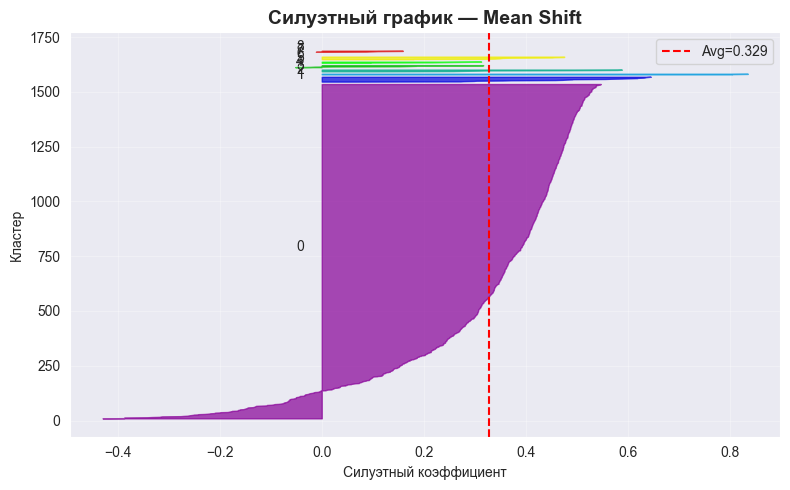

In [9]:
# Силуэтный график
sample_sil = silhouette_samples(X_scaled, labels)
plt.figure(figsize=(8, 5))
y_lower = 10
for i in np.unique(labels):
    vals = np.sort(sample_sil[labels == i])
    y_upper = y_lower + len(vals)
    color = cm.nipy_spectral(float(i+1)/(n_cl+1))
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, color=color)
    plt.text(-0.05, y_lower+0.5*len(vals), str(i))
    y_lower = y_upper + 10
avg = silhouette_score(X_scaled, labels)
plt.axvline(x=avg, color='red', linestyle='--', label=f'Avg={avg:.3f}')
plt.title('Силуэтный график — Mean Shift', fontsize=14, fontweight='bold')
plt.xlabel('Силуэтный коэффициент'); plt.ylabel('Кластер')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()